In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Exploratory Data Analysis (EDA)

This section analyzes the structure, distribution,
and quality of the water potability dataset before
model training.

In [2]:
import pandas as pd

path = "/content/drive/MyDrive/AI-Water-Contamination-Early-Warning-System/data/water_potability.csv"

df = pd.read_csv(path)

df.head()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0


In [4]:
print(df.shape)

df.isnull().sum()

df['potability'].value_counts()

(100000, 10)


,count
potability,
0,92384
1,7616


In [5]:
df.isnull().sum()

,0
ph,3121
hardness,0
tds,2384
chlorine,0
sulfate,813
conductivity,1598
organic_carbon,0
trihalomethanes,0
turbidity,0
potability,0


# Data Preprocessing

This section handles missing values,
class imbalance, and feature scaling
before training machine learning models.

In [6]:
# =========================================
# HANDLE MISSING VALUES
# =========================================

df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

,0
ph,0
hardness,0
tds,0
chlorine,0
sulfate,0
conductivity,0
organic_carbon,0
trihalomethanes,0
turbidity,0
potability,0


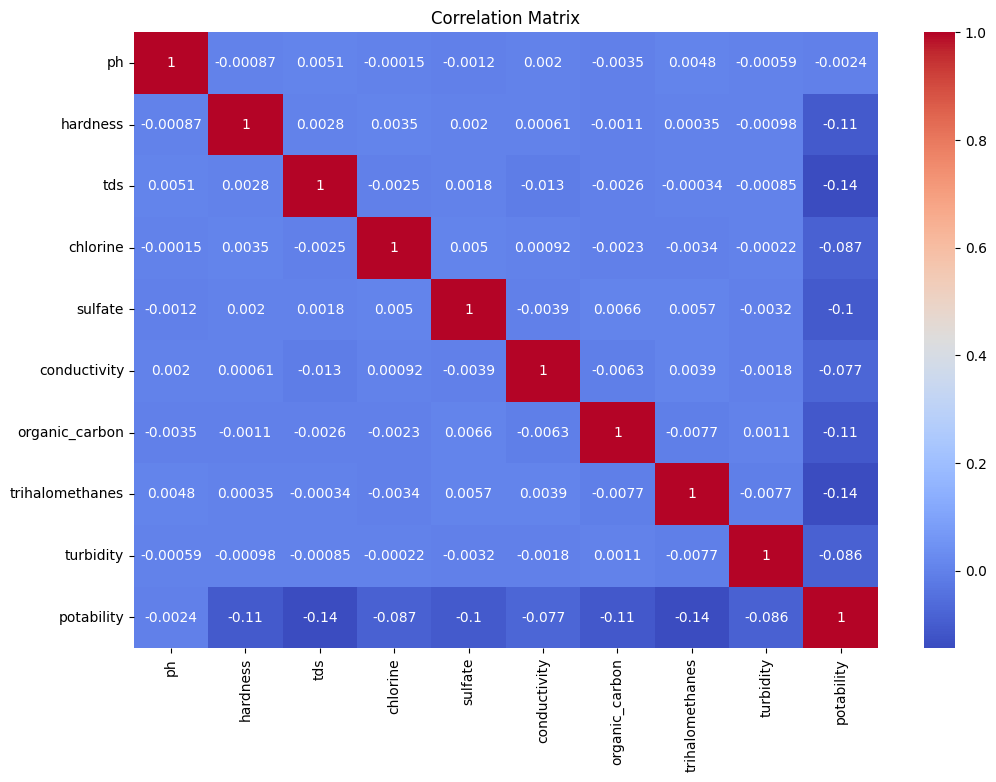

In [8]:
# =========================================
# CORRELATION MATRIX
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

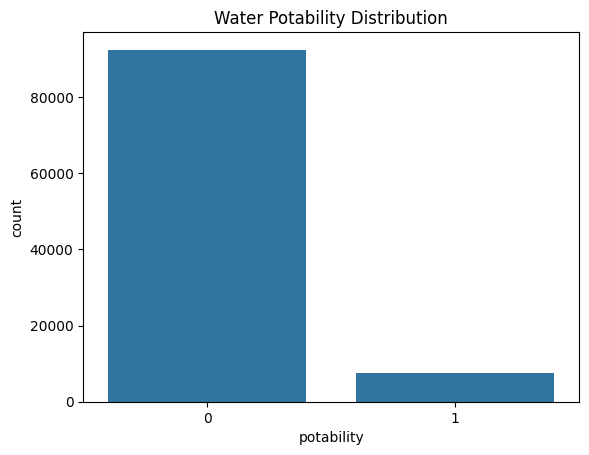

In [9]:
# =========================================
# CLASS DISTRIBUTION
# =========================================

sns.countplot(x='potability', data=df)

plt.title("Water Potability Distribution")

plt.show()

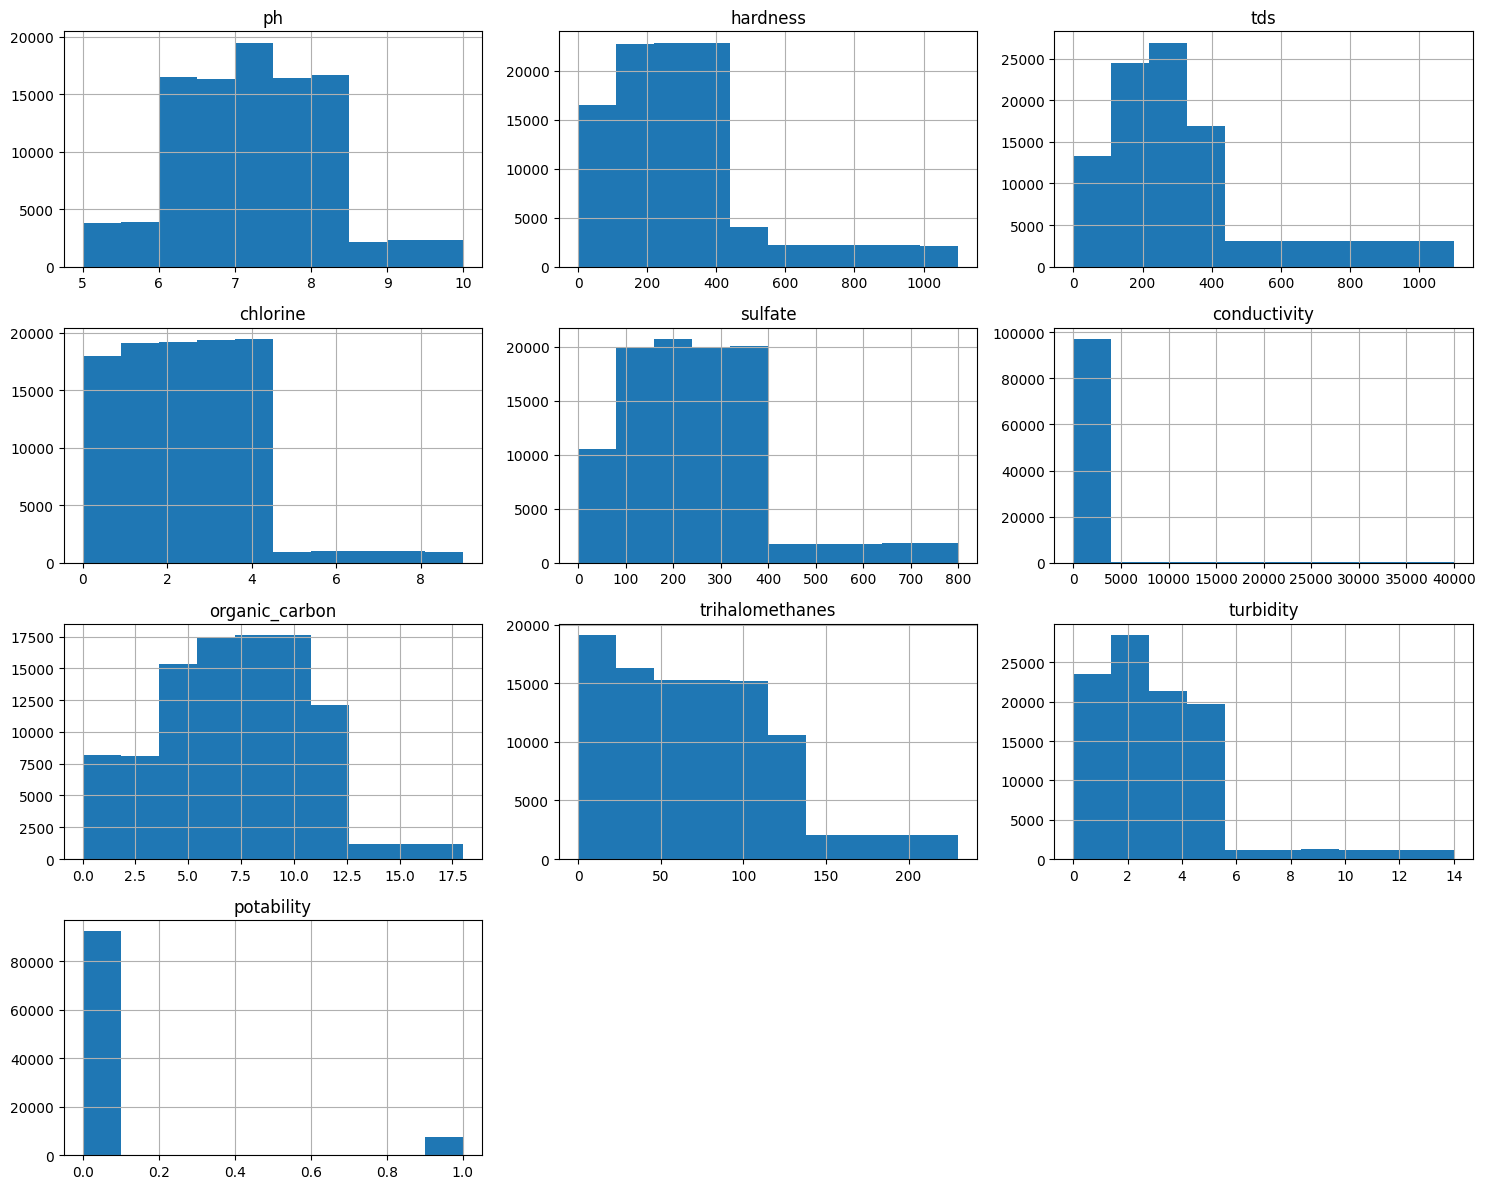

In [10]:
# =========================================
# FEATURE DISTRIBUTIONS
# =========================================

df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

In [11]:
# =========================================
# FEATURE-TARGET SPLIT
# =========================================

X = df.drop('potability', axis=1)

y = df['potability']

print(X.shape)
print(y.shape)

(100000, 9)
(100000,)


In [12]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000, 9)
(20000, 9)


In [13]:
# =========================================
# FEATURE SCALING
# =========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
!pip install imbalanced-learn

In [15]:
# =========================================
# HANDLE CLASS IMBALANCE USING SMOTE
# =========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

potability
0    73907
1     6093
Name: count, dtype: int64
potability
0    73907
1    73907
Name: count, dtype: int64


# Logistic Regression Model

Logistic Regression was used as the baseline
classification model for potable water prediction.

In [16]:
# =========================================
# LOGISTIC REGRESSION
# =========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# Create model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7828

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.78      0.87     18477
           1       0.24      0.82      0.37      1523

    accuracy                           0.78     20000
   macro avg       0.61      0.80      0.62     20000
weighted avg       0.92      0.78      0.83     20000



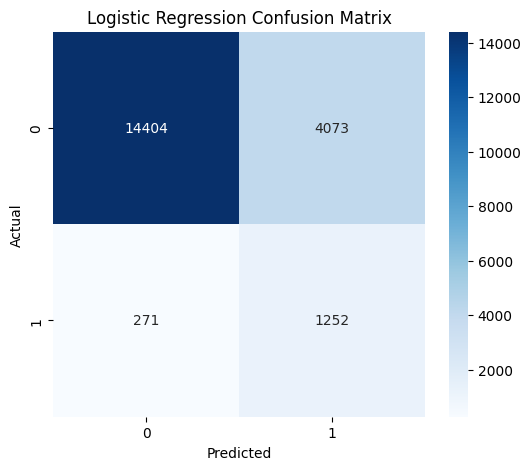

In [17]:
# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Decision Tree Classifier

Decision Tree was used to capture
non-linear relationships among
water quality parameters.

In [18]:
# =========================================
# DECISION TREE
# =========================================

from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train
dt_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9953

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18477
           1       0.97      0.97      0.97      1523

    accuracy                           1.00     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       1.00      1.00      1.00     20000



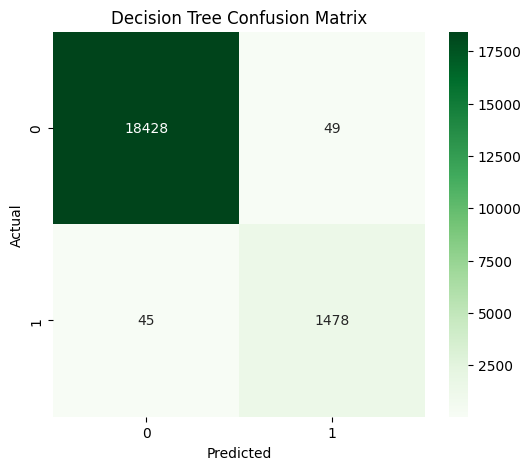

In [19]:
# =========================================
# DECISION TREE CONFUSION MATRIX
# =========================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Random Forest Classifier

Random Forest was employed as an ensemble-based
machine learning model to improve robustness and
generalization performance for water potability prediction.

In [20]:
# =========================================
# RANDOM FOREST
# =========================================

from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9968

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18477
           1       0.97      0.99      0.98      1523

    accuracy                           1.00     20000
   macro avg       0.98      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000



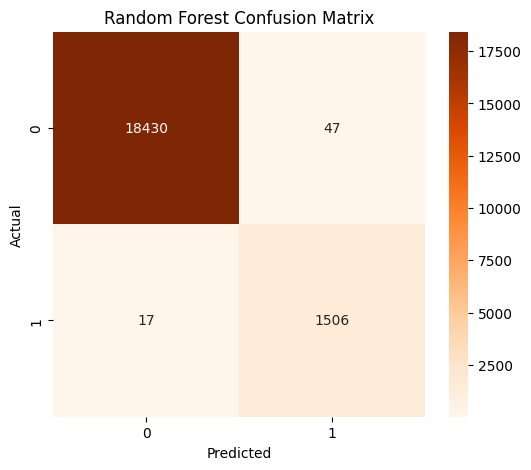

In [21]:
# =========================================
# RANDOM FOREST CONFUSION MATRIX
# =========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
# =========================================
# FEATURE IMPORTANCE
# =========================================

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance)

           feature  importance
5     conductivity    0.222413
2              tds    0.184003
7  trihalomethanes    0.146159
1         hardness    0.113261
6   organic_carbon    0.108549
4          sulfate    0.088106
3         chlorine    0.054758
8        turbidity    0.047036
0               ph    0.035716


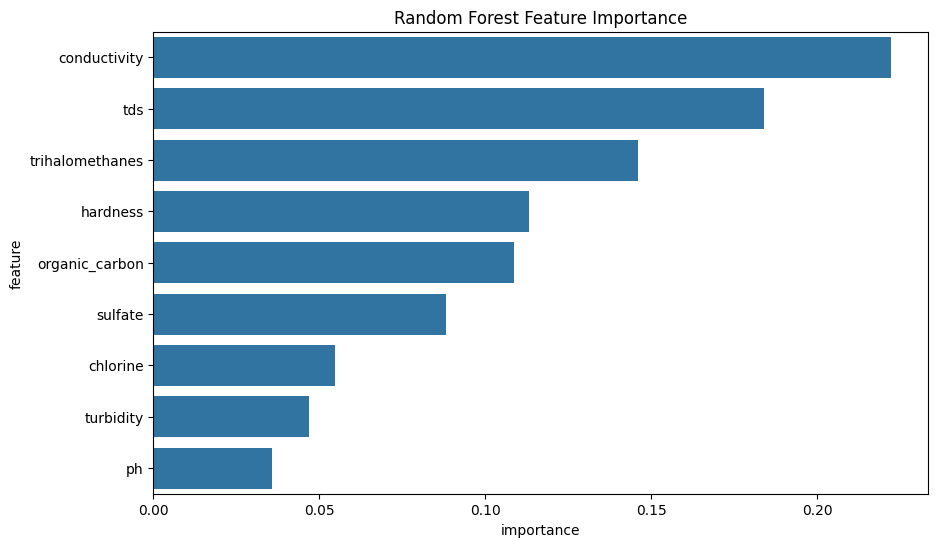

In [23]:
# =========================================
# FEATURE IMPORTANCE PLOT
# =========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")

plt.show()

In [25]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

# Comparative Performance Evaluation

The performance of different machine learning models
was evaluated using accuracy, precision, recall,
and F1-score metrics.

In [26]:
# =========================================
# RESULTS COMPARISON TABLE
# =========================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7828,0.235117,0.822062,0.365654
1,Decision Tree,0.9953,0.967911,0.970453,0.969180
2,Random Forest,0.9968,0.969736,0.988838,0.979194


In [27]:
# =========================================
# SAVE RESULTS TABLE
# =========================================

results_df.to_csv(
    "/content/drive/MyDrive/AI-Water-Contamination-Early-Warning-System/results/model_comparison.csv",
    index=False
)

In [28]:
!pip install shap

In [29]:
# =========================================
# SHAP EXPLAINABILITY
# =========================================

import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP analysis completed.")

SHAP analysis completed.


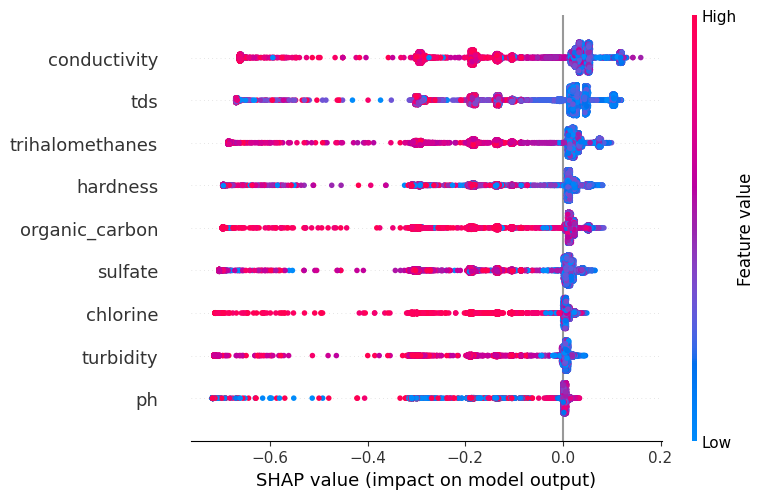

In [31]:
# =========================================
# SHAP SUMMARY PLOT
# =========================================

X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

shap.summary_plot(
    shap_values[:,:,1],
    X_test_df
)

# Cross-Validation

Cross-validation was performed to evaluate
the generalization capability of the proposed model.

In [32]:
# =========================================
# CROSS VALIDATION
# =========================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:\n")

print(cv_scores)

print("\nAverage CV Accuracy:")

print(cv_scores.mean())

Cross Validation Scores:

[0.98849914 0.99888374 0.99864696 0.99864696 0.99881605]

Average CV Accuracy:
0.9966985679129156
